In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random

In [25]:
# Set seeds for reproducibility
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
tf.random.set_seed(42)  # For TensorFlow

In [26]:
# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [27]:
# Function to generate file names based on the input format
print("Note: use results36.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results36.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results36.mat which has 10000 datasets; B only has positive Z values


In [28]:
# Define the list of files that should be processed as HDF5 files
h5_file_numbers = {3, 6, 7, 9}

In [29]:
# Function to load data from .h5 file
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

In [30]:
# Function to load data from .mat file
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

In [31]:
# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

In [32]:
# Function to process data
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

In [33]:
# Main function to determine the type of file and load data accordingly
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

In [34]:
# Example usage
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

Processing results36.mat as a .mat file...


In [35]:
# Data is now loaded and processed.
print("Data reading completed.")

Data reading completed.


In [36]:
# Filter out low-variance columns
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)
start_index, end_index = 0, I_data.shape[1] - 1

In [37]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [38]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [39]:
start_index = 363
end_index = 864

In [40]:
print('start index is', start_index)
print('end index is', end_index)

start index is 363
end index is 864


In [41]:
I_data_filtered = I_data[:, start_index:end_index + 1]
X_data_filtered = X_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

In [42]:
def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

In [43]:
# Resample and smooth the normalized data to ensure each element has a length of 1200
normalized_I_resampled = resample_and_smooth_data(normalized_I, new_length=1200)
X_data_filtered_resampled = resample_and_smooth_data(X_data_filtered, new_length=1200)


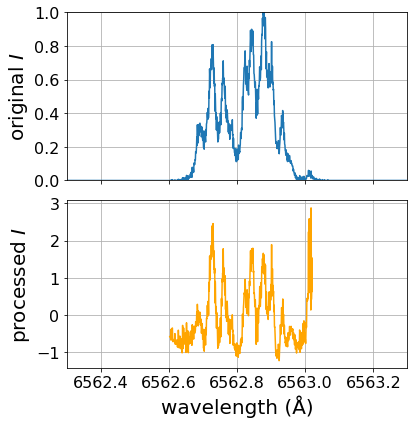

In [44]:
import matplotlib.pyplot as plt

# Row 10 of original and normalized data
index = 600
original_row = I_data[index]
X_resampled = X_data[index]
normalized_row = normalized_I_resampled[index]
X_resampled_filtered = X_data_filtered_resampled[index]

# Adjustable font size
fontsize = 20


# Create subplots with shared X axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

# Plot original data
ax1.plot(X_resampled, original_row, label='Original I_data')
# ax1.set_title('Original I_data values', fontsize=fontsize)
ax1.set_ylabel('original $I$', fontsize=fontsize)
ax1.set_ylim(0, 1)
ax1.set_xlim(6562.3, 6563.3)
ax1.grid(True)

# Plot normalized data
ax2.plot(X_resampled_filtered, normalized_row, label='Normalized I_data', color='orange')
# ax2.set_title('Normalized I_data values', fontsize=fontsize)
ax2.set_xlabel('wavelength (Å)', fontsize=fontsize)
ax2.set_ylabel('processed $I$', fontsize=fontsize)
ax2.set_xlim(6562.3, 6563.3)
ax2.grid(True)

ax1.tick_params(labelsize=fontsize*0.8)
ax2.tick_params(labelsize=fontsize*0.8)

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("/home/botingl/machine learning copy/Plots/noisy_sig_poster.pdf", dpi=300, facecolor='white')

# Show the figure
plt.show()
